<a href="https://colab.research.google.com/github/Viper4/MNIST-CIFAR10-ML-project/blob/main/MNIST_CIFAR_ML_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

S1. Identifying Lucky Numbers

Worldwide, the numbers most commonly considered "lucky" are 3, 7, and 8. We will implement different binary classifiers to classify a given image of a digit from the MNIST dataset as either lucky (if it's 3, 7, or 8) or not lucky (if it's any other digit), and compare their results. In this comparison, we will compare various Scikit-Learn classifiers at this task: Stochastic Gradient Descent (SGD), Logistic Regression, Decision Trees, Random Forests, and XGBoost Trees.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics

torch.set_printoptions(sci_mode=False)

from sklearn.datasets import fetch_openml
mnist = fetch_openml(data_id=554)

In [ ]:
# Normalize data by min-max of 255
mnist_train = mnist.data.values[0:60000,:] / 255.0 #Keep the first 60000 samples for training
mnist_train_labels = mnist.target.values[0:60000].astype(int)
mnist_test = mnist.data.values[60000:,:] / 255.0 #Test on the rest
mnist_test_labels = mnist.target.values[60000:].astype(int)

# Binary labels for if number is lucky (3, 7, or 8) are just the masks as int type
train_lucky_mask = (mnist_train_labels == 3) | (mnist_train_labels == 7) | (mnist_train_labels == 8)
test_lucky_mask = (mnist_test_labels == 3) | (mnist_test_labels == 7) | (mnist_test_labels == 8)

print(f"Data loaded. Training shape: {mnist_train.shape}")
print(f"Target distribution: {np.bincount(train_lucky_mask)} (non-lucky vs lucky)")
print(mnist_train[mnist_train != 0])

Data loaded. Training shape: (60000, 784)
Target distribution: [41753 18247] (non-lucky vs lucky)
[0.01176471 0.07058824 0.07058824 ... 0.75686275 0.77254902 0.5254902 ]


In [ ]:
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, f1_score, accuracy_score, roc_auc_score, precision_score, recall_score

print("Defining models...")
max_iter = 5000
random_state = 42
sgd_clf = SGDClassifier(loss='log_loss', max_iter=max_iter, random_state=random_state)
log_reg_clf = LogisticRegression(max_iter=max_iter, solver='lbfgs')
dt_clf = DecisionTreeClassifier(max_depth=10, random_state=random_state)
rf_clf = RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=-1, random_state=random_state)
svc_clf = SVC(probability=True, kernel='linear', max_iter=max_iter, random_state=random_state)
xgb_clf = XGBClassifier(n_estimators=50, max_depth=5, learning_rate=0.1, random_state=random_state)

models = [
    ("SGD", sgd_clf),
    ("LogReg", log_reg_clf),
    ("DecisionTree", dt_clf),
    ("RandomForest", rf_clf),
    # ("SVC", svc_clf),
    ("XGBoost", xgb_clf)
]

Defining models...


In [ ]:
def evaluate_models(model_list, X, y):
    for name, clf in model_list:
        print(f"\nEvaluating {name} (5-Fold CV)...")
        cv_results = cross_validate(clf, X, y, cv=5, scoring=['accuracy', 'roc_auc', 'f1', 'average_precision'])

        avg_acc = cv_results['test_accuracy'].mean()
        avg_auc = cv_results['test_roc_auc'].mean()
        avg_f1 = cv_results['test_f1'].mean()
        avg_pr_auc = cv_results['test_average_precision'].mean()

        print(f" -> Split Accuracies: {cv_results['test_accuracy']}")
        print(f" -> Split ROC-AUCs: {cv_results['test_roc_auc']}")
        print(f" -> Split F1s: {cv_results['test_f1']}")
        print(f" -> Split PR-AUC: {cv_results['test_average_precision']}")

        print(f" -> Avg Accuracy: {avg_acc:.4f}")
        print(f" -> Avg ROC-AUC:  {avg_auc:.4f}")
        print(f" -> Avg F1-Score: {avg_f1:.4f}")
        print(f" -> Avg PR-AUC:   {avg_pr_auc:.4f}")

        print(f" -> Std Accuracy: {cv_results['test_accuracy'].std():.4f}")
        print(f" -> Std ROC-AUC:  {cv_results['test_roc_auc'].std():.4f}")
        print(f" -> Std F1:       {cv_results['test_f1'].std():.4f}")
        print(f" -> Std PR-AUC:   {cv_results['test_average_precision'].std():.4f}")

evaluate_models(models, mnist_train, train_lucky_mask.astype(int))


Evaluating SGD (5-Fold CV)...
 -> Split Accuracies: [0.874      0.85566667 0.86883333 0.87       0.8805    ]
 -> Split ROC-AUCs: [0.92865732 0.92998887 0.92314017 0.92549238 0.93685853]
 -> Split F1s: [0.78601755 0.78527151 0.78379121 0.7809604  0.80473856]
 -> Split PR-AUC: [0.86495765 0.8655636  0.85371943 0.86290855 0.88081112]
 -> Avg Accuracy: 0.8698
 -> Avg ROC-AUC:  0.9288
 -> Avg F1-Score: 0.7882
 -> Avg PR-AUC:   0.8656
 -> Std Accuracy: 0.0082
 -> Std ROC-AUC:  0.0047
 -> Std F1:       0.0085
 -> Std PR-AUC:   0.0087

Evaluating LogReg (5-Fold CV)...
 -> Split Accuracies: [0.87475    0.87583333 0.87066667 0.87033333 0.88216667]
 -> Split ROC-AUCs: [0.92951645 0.93309548 0.9283013  0.92790137 0.93844393]
 -> Split F1s: [0.78604982 0.79073034 0.77777778 0.77598618 0.79753723]
 -> Split PR-AUC: [0.86701729 0.87373442 0.86212655 0.86372889 0.88369634]
 -> Avg Accuracy: 0.8748
 -> Avg ROC-AUC:  0.9315
 -> Avg F1-Score: 0.7856
 -> Avg PR-AUC:   0.8701
 -> Std Accuracy: 0.0043
 -> 

In [ ]:
print("Training models on full training set...")
for name, model in models:
    print(f"Training {name}...")
    model.fit(mnist_train, train_lucky_mask.astype(int))

# Get probabilities for the lucky numbers (3, 7, 8) on the testing data
model_probs = []
for name, model in models:
    model_probs.append((name, model.predict_proba(mnist_test)[:, 1]))

print("Probabilities calculated.")

#print(model_probs)

Training models on full training set...
Training SGD...
Training LogReg...
Training DecisionTree...
Training RandomForest...
Training XGBoost...
Probabilities calculated.


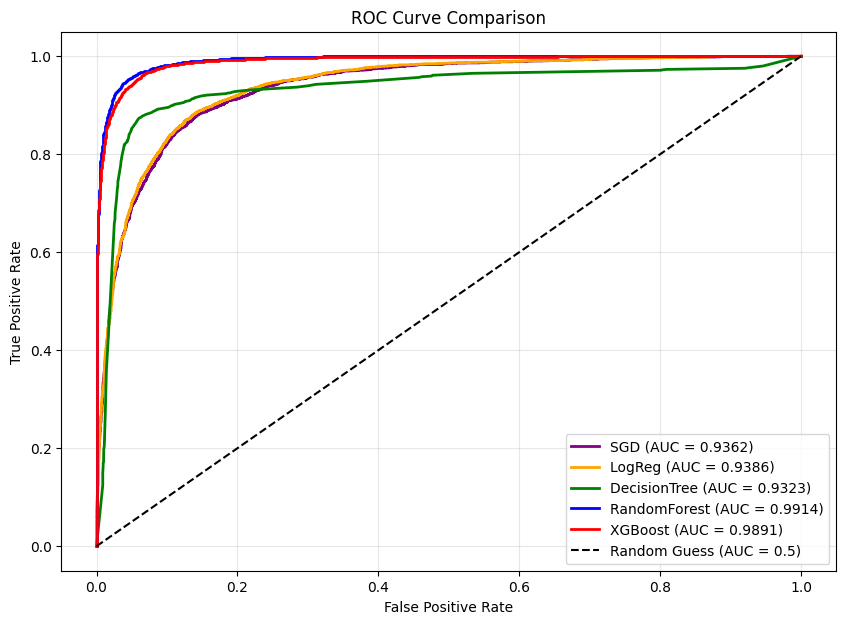

In [ ]:
def plot_roc_curve(y_true, prob_list):
    plt.figure(figsize=(10, 7))
    colors = ['purple', 'orange', 'green', 'blue', 'red', 'brown']

    for (name, probs), color in zip(prob_list, colors):
        fpr, tpr, _ = roc_curve(y_true, probs)
        score = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {score:.4f})', color=color, lw=2)

    plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5)')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve Comparison')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

plot_roc_curve(test_lucky_mask.astype(int), model_probs)

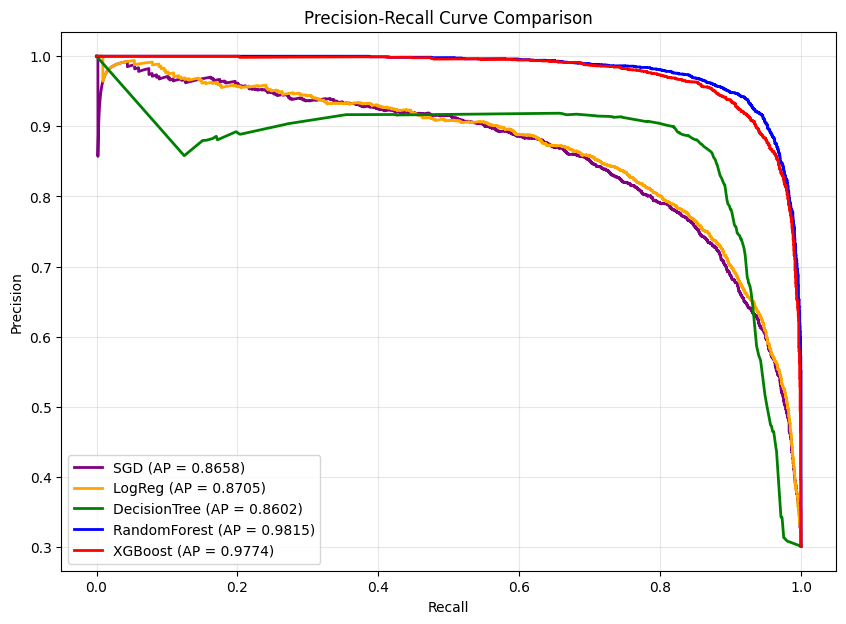

In [ ]:
def plot_pr_curve(y_true, prob_list):
    plt.figure(figsize=(10, 7))
    colors = ['purple', 'orange', 'green', 'blue', 'red', 'brown']

    for (name, probs), color in zip(prob_list, colors):
        prec, rec, _ = precision_recall_curve(y_true, probs)
        ap = average_precision_score(y_true, probs)
        plt.plot(rec, prec, label=f'{name} (AP = {ap:.4f})', color=color, lw=2)

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve Comparison')
    plt.legend(loc="lower left")
    plt.grid(alpha=0.3)
    plt.show()

plot_pr_curve(test_lucky_mask.astype(int), model_probs)

In [ ]:
# Metrics by 3, 7, 8 labels
nums = [3, 7, 8]

print("Metrics by digit (3 vs rest, 7 vs rest, 8 vs rest)")

for name, probs in model_probs:
    print(f"\n{name} metrics:")

    for num in nums:
        # Ground truth: this digit vs everything else
        y_true_digit = (mnist_test_labels == num).astype(int)

        # Predictions (thresholded for classification metrics)
        y_pred_digit = (probs > 0.5).astype(int)

        print(f" {num}:")
        print(f"  Accuracy:  {accuracy_score(y_true_digit, y_pred_digit):.4f}")
        print(f"  F1 Score:  {f1_score(y_true_digit, y_pred_digit):.4f}")
        print(f"  Precision: {precision_score(y_true_digit, y_pred_digit):.4f}")
        print(f"  Recall:    {recall_score(y_true_digit, y_pred_digit):.4f}")
        print(f"  ROC AUC:   {roc_auc_score(y_true_digit, probs):.4f}")
        print(f"  PR AUC:    {average_precision_score(y_true_digit, probs):.4f}")

Metrics by digit (3 vs rest, 7 vs rest, 8 vs rest)

SGD metrics:
 3:
  Accuracy:  0.7657
  F1 Score:  0.4250
  Precision: 0.2825
  Recall:    0.8574
  ROC AUC:   0.8635
  PR AUC:    0.3143
 7:
  Accuracy:  0.7573
  F1 Score:  0.4070
  Precision: 0.2718
  Recall:    0.8103
  ROC AUC:   0.8532
  PR AUC:    0.3675
 8:
  Accuracy:  0.7405
  F1 Score:  0.3575
  Precision: 0.2356
  Recall:    0.7413
  ROC AUC:   0.7984
  PR AUC:    0.2162

LogReg metrics:
 3:
  Accuracy:  0.7858
  F1 Score:  0.4413
  Precision: 0.2996
  Recall:    0.8376
  ROC AUC:   0.8673
  PR AUC:    0.3114
 7:
  Accuracy:  0.7794
  F1 Score:  0.4273
  Precision: 0.2914
  Recall:    0.8006
  ROC AUC:   0.8725
  PR AUC:    0.4409
 8:
  Accuracy:  0.7494
  F1 Score:  0.3402
  Precision: 0.2288
  Recall:    0.6632
  ROC AUC:   0.7801
  PR AUC:    0.1917

DecisionTree metrics:
 3:
  Accuracy:  0.7798
  F1 Score:  0.4453
  Precision: 0.2986
  Recall:    0.8752
  ROC AUC:   0.8648
  PR AUC:    0.3537
 7:
  Accuracy:  0.7784
  F

S2. CIFAR-10

Using PyTroch, we will create a custom CNN model that classifies the CIFAR 10 images into one of the 10 image classes.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torchvision
import torchvision.datasets as dsets
import torchvision.transforms as transforms

use_cuda = torch.cuda.is_available()
print("Using GPU?:",use_cuda)
if (use_cuda):
  print("GPU Name:",torch.cuda.get_device_name())
  device = torch.device("cuda")
else:
  device = torch.device("cpu")

Using GPU?: True
GPU Name: NVIDIA RTX PRO 6000 Blackwell Server Edition


In [ ]:
def train(network,  data_generator, loss_function, optimizer, scheduler, logging = 200):
  network.train() #updates any network layers that behave differently in training and execution
  avg_loss = 0
  num_batches = 0
  for batch, (input_data, target_output) in enumerate(data_generator):
    input_data, target_output = input_data.to(device), target_output.to(device)
    optimizer.zero_grad()                            # Gradients need to be reset each batch
    prediction = network(input_data)                 # Forward pass: compute the output class given a image
    loss = loss_function(prediction, target_output)  # Compute the loss: difference between the output and correct result
    loss.backward()                                  # Backward pass: compute the gradients of the model with respect to the loss
    optimizer.step()
    scheduler.step()
    avg_loss += loss.item()
    num_batches += 1
    if ((batch+1)%logging == 0): print('Batch [%d/%d], Train Loss: %.4f' %(batch+1, len(data_generator.dataset)/len(target_output), avg_loss/num_batches))
  return avg_loss/num_batches

def test(network, test_loader, loss_function):
  network.eval() #updates any network layers that behave differently in training and execution
  test_loss = 0
  num_batches = 0
  with torch.no_grad():
    for data, target in test_loader:
      data, target = data.to(device), target.to(device)
      output = network(data)
      test_loss += loss_function(output, target).item()
      pred = output.data.max(1, keepdim=True)[1]
      num_batches += 1
  test_loss /= num_batches
  #print('\nTest set: Avg. loss: {:.4f})\n'.format(test_loss))
  return test_loss

def computeLabelAccuracy(networkModel, data_loader, label_text=""):
  test_loss = 0
  correct = 0
  networkModel.eval()
  with torch.no_grad():
    for data, target in data_loader:
      data, target = data.to(device), target.to(device)
      output = networkModel(data)
      pred = output.data.max(1, keepdim=True)[1]  #Check if the maximum/largest output class matches the label
      correct += pred.eq(target.data.view_as(pred)).sum()
  print('\n{}: Accuracy: {}/{} ({:.1f}%)'.format(
    label_text, correct, len(data_loader.dataset),
    100. * correct / len(data_loader.dataset)))

def drawPredictionsCIFAR10(networkModel, dataset, mean_r, mean_g, mean_b, std_r, std_g, std_b, num_rows=6, num_cols = 10, skip_batches=0):
  #Plot some of the testing results
  networkModel.eval()
  data_generator = torch.utils.data.DataLoader(dataset, batch_size=num_rows*num_cols)
  data_enumerator = enumerate(data_generator)
  for i in range(skip_batches):
     _, (images,labels) = next(data_enumerator) #skip a few batches if needed
  _, (images,labels) = next(data_enumerator)
  images, labels = images.to(device), labels.to(device)
  with torch.no_grad():
    pred_catigories = networkModel(images) #all 10 values
    pred_labels = pred_catigories.data.max(1, keepdim=True)[1] #only the highest value is the final prediction

  # Calculate mean and std of RGB channels for unnormalize
  mean = torch.tensor([mean_r, mean_g, mean_b]).view(3, 1, 1).to(device)
  std  = torch.tensor([std_r,  std_g,  std_b ]).view(3, 1, 1).to(device)
  for row in range(num_rows):
    fig = plt.figure(figsize=(num_cols+6,5)) #adjust the plot size
    for i in range(num_cols):
      plt.subplot(1,num_cols,i+1)
      cur = i + row*num_cols
      #plt.tight_layout()
      drawColor = 'black'
      if pred_labels[cur].item() != labels[cur]:
        drawColor = 'red'
      # unnormalize
      img = images[cur] * std + mean
      #img = images[cur] / 2 + 0.5     # unnormalize
      npimg = img.cpu().numpy()
      plt.imshow(np.transpose(npimg, (1, 2, 0)))  #, interpolation='none'
      plt.title(" O: {},\n L: {}".format(classes[pred_labels[cur].item()],classes[labels[cur]]), color=drawColor)
      plt.xticks([])
      plt.yticks([])

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def logResults(epoch, num_epochs, train_loss, train_loss_history, test_loss, test_loss_history, epoch_counter, print_interval=1000):
  if (epoch%print_interval == 0):  print('Epoch [%d/%d], Train Loss: %.4f, Test Loss: %.4f' %(epoch+1, num_epochs, train_loss, test_loss))
  train_loss_history.append(train_loss)
  test_loss_history.append(test_loss)
  epoch_counter.append(epoch)

def graphLoss(epoch_counter, train_loss_hist, test_loss_hist, loss_name="Loss", start = 0):
  fig = plt.figure()
  plt.plot(epoch_counter[start:], train_loss_hist[start:], color='blue')
  plt.plot(epoch_counter[start:], test_loss_hist[start:], color='red')
  plt.legend(['Train Loss', 'Test Loss'], loc='upper right')
  plt.xlabel('#Epochs')
  plt.ylabel(loss_name)

def trainAndGraph(network, training_generator, testing_generator, loss_function, optimizer, scheduler, num_epochs, learning_rate, logging_interval=1):
  #Arrays to store training history
  test_loss_history = []
  epoch_counter = []
  train_loss_history = []
  last_loss = 999999
  best_loss = 999999
  for epoch in range(num_epochs):
    avg_loss = train(network, training_generator, loss_function, optimizer, scheduler)
    test_loss = test(network, testing_generator, loss_function)

    logResults(epoch, num_epochs, avg_loss, train_loss_history, test_loss, test_loss_history, epoch_counter, logging_interval)
    if (test_loss < best_loss):
      best_loss = test_loss
      torch.save(network.state_dict(), 'best_model.pt')
      print("Saved model to 'best_model.pt'")
    last_loss = test_loss
    old_params = network.parameters()

    if (epoch%logging_interval == 0):
      current_lr = optimizer.param_groups[0]['lr']
      print("Learning Rate:", current_lr)

  graphLoss(epoch_counter, train_loss_history, test_loss_history)

In [ ]:
class GaussianNoise(nn.Module):
    def __init__(self, std=0.05):
        super().__init__()
        self.std = std

    def forward(self, x):
        if self.training and self.std > 0:
            return x + torch.randn_like(x) * self.std
        return x

In [ ]:
class Conv_downsample_block(nn.Module):
  def __init__(self, channels_in, channels_out, activation_function):
      super().__init__()
      ks = 3 #I'm lazy so this is hard-coded, but you should pass this parameter in at try 5x5 kernels
      self.conv = nn.Conv2d(channels_in, channels_out, kernel_size=ks, padding=1) #Passing = 1 -> no shrinking
      self.bn = nn.BatchNorm2d(channels_out)
      self.activation_function = activation_function

  def forward(self, x):       # Forward pass which defines how the layers relate the input x to the output out
      x = self.conv(x)
      x = self.bn(x)
      x = self.activation_function(x)
      x = F.max_pool2d(x,kernel_size=2)
      return x

In [ ]:
class Conv_residual_block(nn.Module):
    def __init__(self, channels, activation_function):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)
        self.activation_function = activation_function

    def forward(self, x):
        identity = x # Skip connection

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.activation_function(x)

        x = self.conv2(x)
        x = self.bn2(x)

        x += identity # Residual connection
        x = self.activation_function(x)

        return x

In [ ]:
class CNN(nn.Module):
  def __init__(self, img_w, img_h, num_classes,
               channels=[16, 32, 64],
               blocks_per_stage=[2, 2, 2],
               noise_std=0.0,
               dropout_rate=0.0,
               activation_function=nn.GELU()):
    super().__init__()

    self.noise = GaussianNoise(noise_std)
    self.dropout = nn.Dropout(p=dropout_rate)

    self.stages = nn.ModuleList()
    in_channels = 3

    #-- Blocks
    for i in range(len(channels)):
      out_channels = channels[i]

      # Downsample block
      conv_block = Conv_downsample_block(in_channels, out_channels, activation_function)
      # Max pool inside Conv_downsample_block shrinks size 2x
      img_w //= 2
      img_h //= 2

      # Residual blocks (configurable)
      res_blocks = nn.Sequential(*[
          Conv_residual_block(out_channels, activation_function)
          for _ in range(blocks_per_stage[i])
      ])

      self.stages.append(nn.Sequential(conv_block, res_blocks))

      in_channels = out_channels

    #-- Classifier
    self.linear = nn.Linear(channels[-1], num_classes) # Since we're doing avg pool at the end

  def forward(self, x):       # Forward pass which defines how the layers relate the input x to the output out
    x = self.noise(x) # Add random Gaussian noise to input

    for stage in self.stages:
      x = stage(x)

    x = F.avg_pool2d(x, kernel_size=x.size()[2:]) # Global pooling by avg over image
    x = x.view(x.size(0), -1) #
    x = self.dropout(x)
    return self.linear(x)

In [ ]:
# Download and augment CIFAR data

# Keep runs consistent
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed(0)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

image_w = 32
image_h = 32


training_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transforms.ToTensor())

testing_dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transforms.ToTensor())

imgs = [item[0] for item in training_dataset] # item[0] and item[1] are image and its label
imgs = torch.stack(imgs, dim=0).numpy()

# calculate mean over each channel (r,g,b)
mean_r = imgs[:,0,:,:].mean()
mean_g = imgs[:,1,:,:].mean()
mean_b = imgs[:,2,:,:].mean()
print(mean_r,mean_g,mean_b)

# calculate std over each channel (r,g,b)
std_r = imgs[:,0,:,:].std()
std_g = imgs[:,1,:,:].std()
std_b = imgs[:,2,:,:].std()
print(std_r,std_g,std_b)

# Define data transforms
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),                         #Random cropping
    transforms.RandomHorizontalFlip(),                            #Random flipping
    transforms.RandomAffine(degrees=10, translate=(0.05, 0.05)),  #Random Rotation and translation
    transforms.ToTensor(),
    transforms.Normalize((mean_r, mean_g, mean_b), (std_r, std_g, std_b))
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((mean_r, mean_g, mean_b), (std_r, std_g, std_b))
])

# Load CIFAR-10 data
training_dataset_augment = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
testing_dataset_augment = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

0.49139968 0.48215827 0.44653124
0.24703233 0.24348505 0.26158768


Num. Parameters: 24215178
Data is Loaded
Batch [200/500], Train Loss: 1.7284
Batch [400/500], Train Loss: 1.5838
Epoch [1/20], Train Loss: 1.5317, Test Loss: 1.2476
Saved model to 'best_model.pt'
Learning Rate: 0.001043497143881713
Batch [200/500], Train Loss: 1.2456
Batch [400/500], Train Loss: 1.2036
Epoch [2/20], Train Loss: 1.1862, Test Loss: 1.1944
Saved model to 'best_model.pt'
Learning Rate: 0.002801451669616887
Batch [200/500], Train Loss: 1.0584
Batch [400/500], Train Loss: 1.0214
Epoch [3/20], Train Loss: 1.0044, Test Loss: 0.8566
Saved model to 'best_model.pt'
Learning Rate: 0.0052025141120453046
Batch [200/500], Train Loss: 0.8833
Batch [400/500], Train Loss: 0.8714
Epoch [4/20], Train Loss: 0.8638, Test Loss: 0.8504
Saved model to 'best_model.pt'
Learning Rate: 0.007602902461173492
Batch [200/500], Train Loss: 0.7852
Batch [400/500], Train Loss: 0.7679
Epoch [5/20], Train Loss: 0.7669, Test Loss: 0.6936
Saved model to 'best_model.pt'
Learning Rate: 0.009359015447471895
Bat

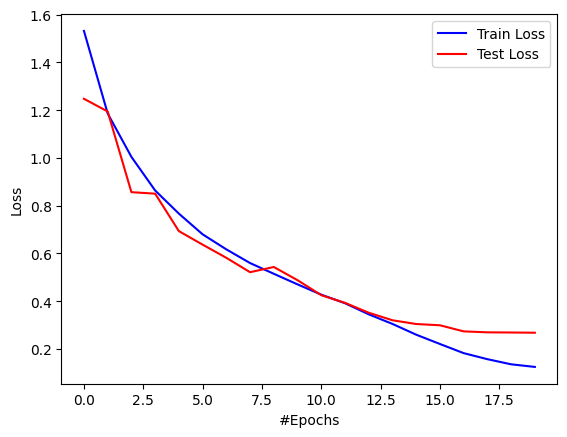

In [ ]:
#Training hyperparameters
num_epochs = 20
print_interval = 1
learning_rate = 0.01
batch_size = 100
channels = [64, 128, 256, 512]
blocks_per_stage = [3, 4, 6, 3]
noise_std = 0.05 # Standard deviation of the Gaussian noise to add to input images
dropout_rate = 0.1 # Chance for each parameter to be zeroed
activation_function = nn.Mish()

#Create model
network = CNN(image_w, image_h, 10, channels, blocks_per_stage, noise_std, dropout_rate, activation_function)
network = network.to(device)

print("Num. Parameters:", count_parameters(network))

#Load the data, and split it into batches
training_generator = torch.utils.data.DataLoader(training_dataset_augment, batch_size=batch_size, shuffle=True)
testing_generator = torch.utils.data.DataLoader(testing_dataset_augment, batch_size=batch_size, shuffle=False)

#Set optimizer and loss function
optimizer = torch.optim.Adam(network.parameters(), lr=learning_rate)
loss_function = nn.CrossEntropyLoss()
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs) # Full cosine cycle after num_epochs
scheduler = torch.optim.lr_scheduler.OneCycleLR(
  optimizer, max_lr=learning_rate, steps_per_epoch=len(training_generator), epochs=num_epochs
)

print("Data is Loaded")

trainAndGraph(network, training_generator, testing_generator, loss_function, optimizer, scheduler, num_epochs, learning_rate, print_interval)


Train Set: Accuracy: 47997/50000 (96.0%)

Test Set: Accuracy: 9168/10000 (91.7%)


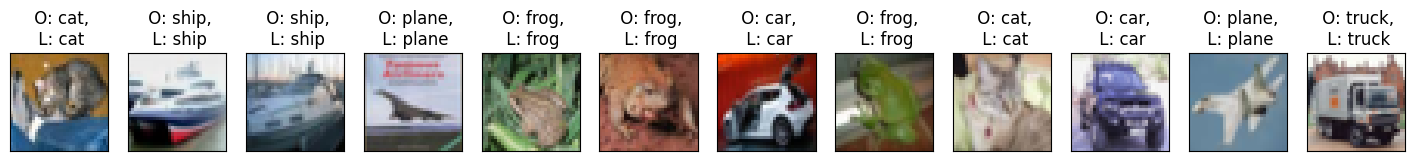

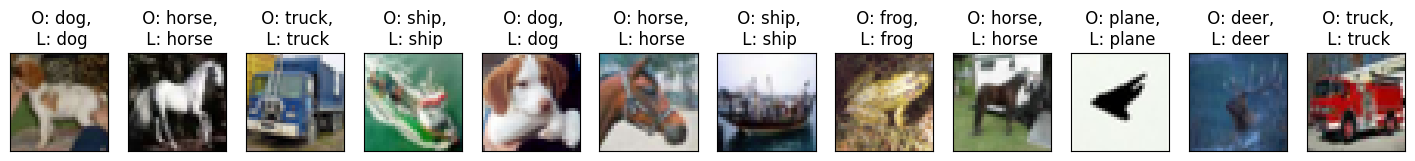

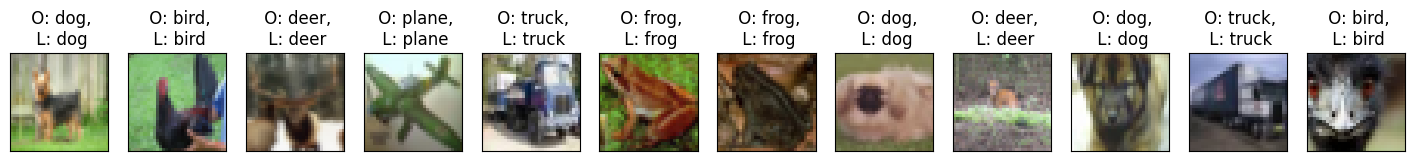

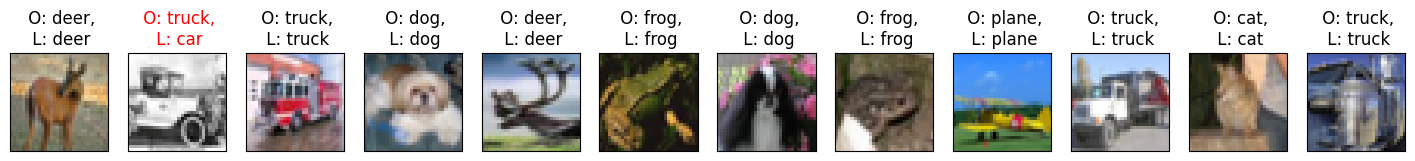

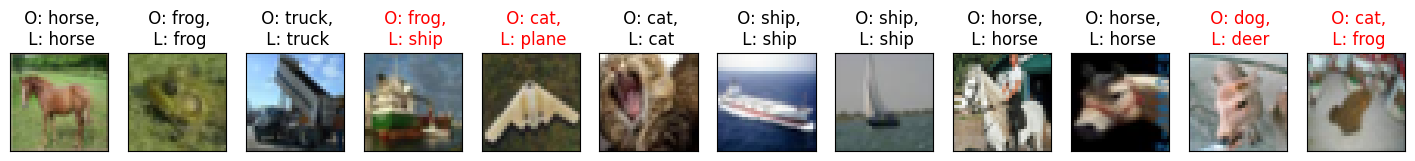

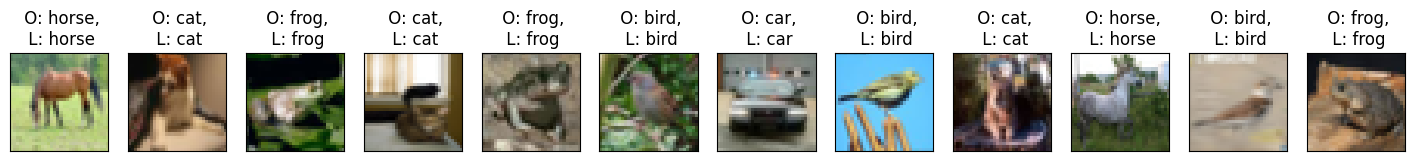

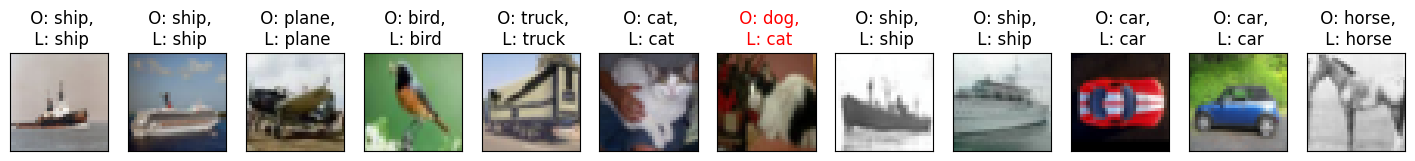

In [ ]:
computeLabelAccuracy(network, training_generator, "Train Set")
computeLabelAccuracy(network, testing_generator, "Test Set")
drawPredictionsCIFAR10(network, testing_dataset_augment, mean_r, mean_g, mean_b, std_r, std_g, std_b, 7, 12, 0)

S3. Modeling Saving & Loading

We will save the best model weights to an external file and then load those saved weights into a fresh model. Then, we will initialize a new, untrained instance of the model architecture, and load the saved weights from the saved file. We then compute the classification accuracy of this loaded model to ensure it matches exactly the accuracy reported in S2.

In [ ]:
# Load best_model.pt and check if test accuracy is the same
loaded_network = CNN(image_w, image_h, 10, channels, blocks_per_stage, noise_std, dropout_rate, activation_function)
loaded_network.load_state_dict(torch.load('best_model.pt', weights_only=True))
loaded_network = loaded_network.to(device)
computeLabelAccuracy(loaded_network, testing_generator, "Test Set")


Test Set: Accuracy: 9168/10000 (91.7%)


S4. Visual Analysis & Evaluation

Using only the loaded model from S3, we evaluate its performance on the CIFAR-10 test set via the following:

* Classification Accuracy: The final prediction accuracy on the full testing dataset
* Confusion Matrix: A confusion matrix for the test set.
* Most Confident Images: For each of the 10 classes, we find and display the single image in the test set that the model is most confident in predicting correctly.
* Misclassifications: We will find and display a few misclassified test images for each of the top 5 most common misclassification types.


In [ ]:
computeLabelAccuracy(loaded_network, testing_generator, "Test Set")


Test Set: Accuracy: 9168/10000 (91.7%)


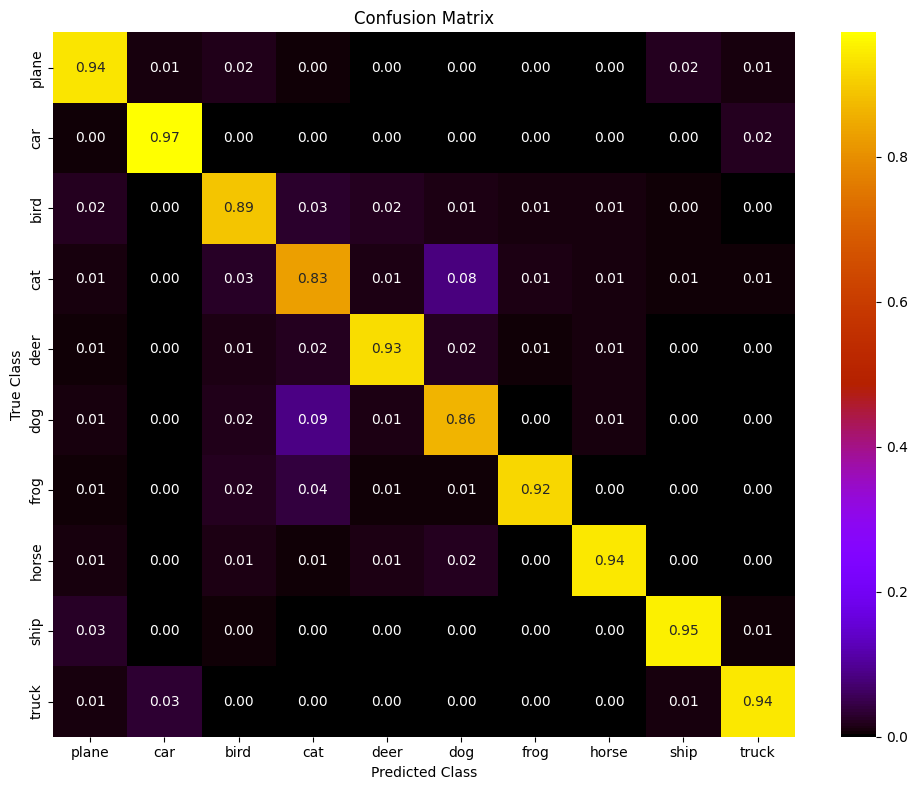

In [ ]:
# Confusion matrix
from sklearn.metrics import confusion_matrix

# Get predictions across all batches
all_preds = []
all_labels = []
loaded_network.eval()
with torch.no_grad():
  for data, target in testing_generator:
    data, target = data.to(device), target.to(device)
    output = loaded_network(data)
    preds = output.argmax(dim=1)
    all_preds.extend(preds.cpu().numpy())
    all_labels.extend(target.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds, normalize='true')  # normalize per true class (row)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='gnuplot', xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

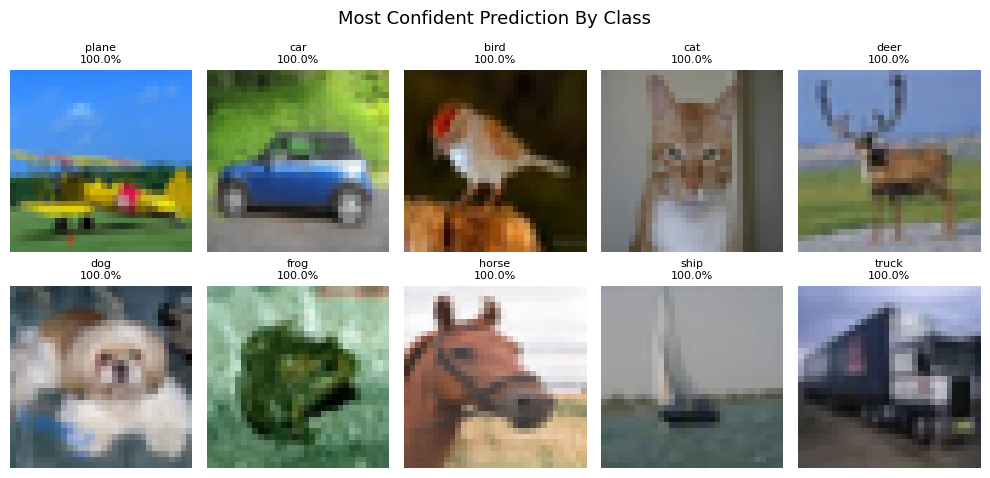

In [ ]:
# Find most confident images in each class
best = {i: (0.0, None) for i in range(10)}

loaded_network.eval()
with torch.no_grad():
  for data, target in testing_generator:
    data, target = data.to(device), target.to(device)
    probs = F.softmax(loaded_network(data), dim=1)
    preds = probs.argmax(dim=1)

    for j in range(len(target)):
      true_label = target[j].item()
      pred_label = preds[j].item()
      confidence = probs[j, pred_label].item()
      if pred_label == true_label and confidence > best[true_label][0]:
        best[true_label] = (confidence, data[j].cpu())

mean_t = torch.tensor([mean_r, mean_g, mean_b]).view(3, 1, 1)
std_t  = torch.tensor([std_r,  std_g,  std_b ]).view(3, 1, 1)

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
fig.suptitle("Most Confident Prediction By Class", fontsize=13)

for i in range(10):
    row, col = i // 5, i % 5
    ax = axes[row, col]
    conf, img_tensor = best[i]
    img = (img_tensor * std_t + mean_t).clamp(0, 1).numpy().transpose(1, 2, 0)
    ax.imshow(img)
    ax.set_title(f"{classes[i]}\n{conf:.1%}", fontsize=8)
    ax.axis('off')

sns.despine()
plt.tight_layout()
plt.show()

Top 5 misclassification types:
  True: dog      -> Predicted: cat       (86 times)
  True: cat      -> Predicted: dog       (81 times)
  True: frog     -> Predicted: cat       (39 times)
  True: truck    -> Predicted: car       (32 times)
  True: bird     -> Predicted: cat       (28 times)


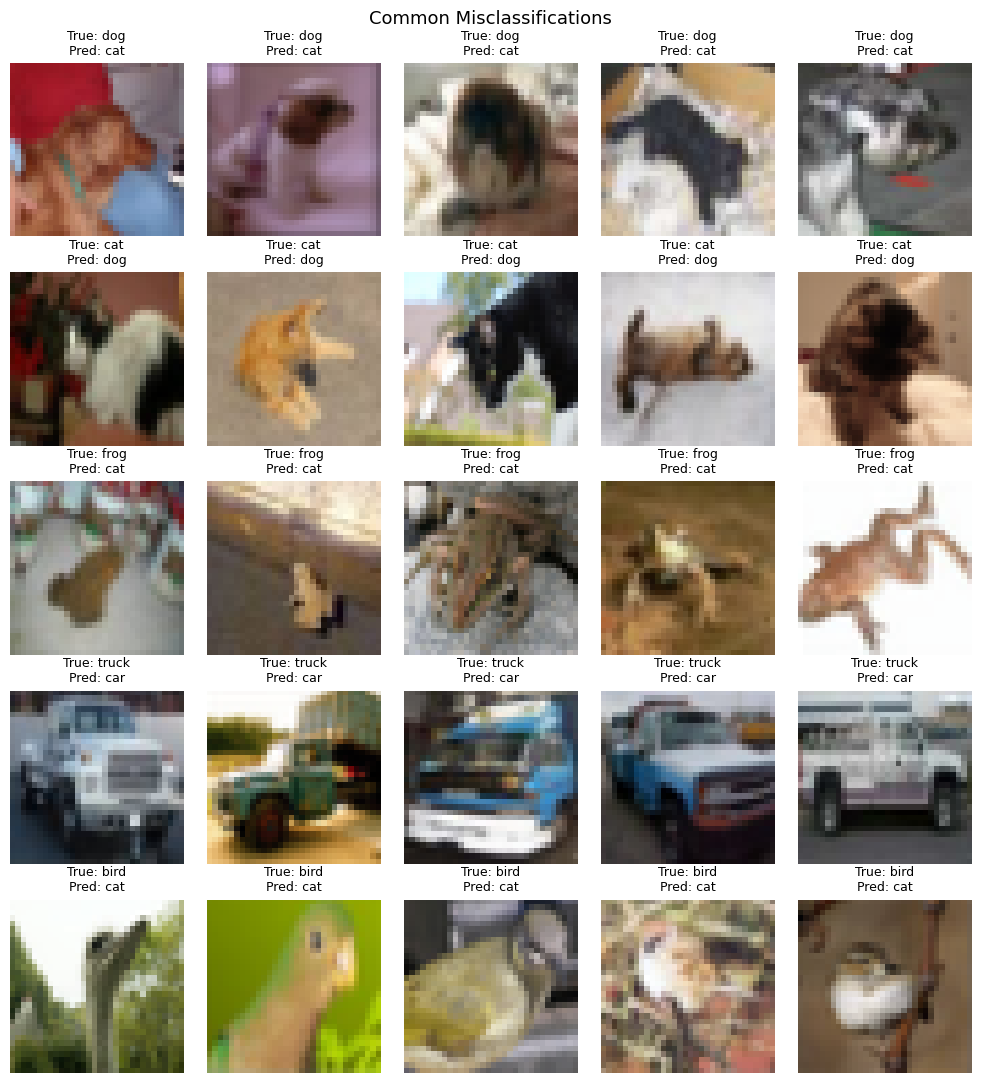

In [ ]:
# Find and display a few misclassified test images for each of the top 5 most common misclassification types
cm_counts = confusion_matrix(all_labels, all_preds)  # raw counts for finding top misclassifications
cm_no_diag = cm_counts.copy()
np.fill_diagonal(cm_no_diag, 0)

top5_flat = np.argsort(cm_no_diag.ravel())[::-1][:5]
top5_pairs = [(idx // 10, idx % 10) for idx in top5_flat]

print("Top 5 misclassification types:")
for true_l, pred_l in top5_pairs:
  print(f"  True: {classes[true_l]:8s} -> Predicted: {classes[pred_l]:8s}  ({cm_counts[true_l, pred_l]} times)")

# Collect examples
num_examples = 5
examples = {pair: [] for pair in top5_pairs}

loaded_network.eval()
with torch.no_grad():
  for data, target in testing_generator:
    data, target = data.to(device), target.to(device)
    preds = loaded_network(data).argmax(dim=1)
    for j in range(len(target)):
      pair = (target[j].item(), preds[j].item())
      if pair in examples and len(examples[pair]) < num_examples:
        examples[pair].append(data[j].cpu())
    if all(len(v) >= num_examples for v in examples.values()):
      break

# Plot
fig, axes = plt.subplots(len(top5_pairs), num_examples, figsize=(num_examples * 2, len(top5_pairs) * 2 + 1))
fig.suptitle("Common Misclassifications", fontsize=13)

for row, (true_l, pred_l) in enumerate(top5_pairs):
  for col in range(num_examples):
    ax = axes[row][col]
    img = examples[(true_l, pred_l)][col]
    img = (img * std_t + mean_t).clamp(0, 1).numpy().transpose(1, 2, 0)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"True: {classes[true_l]}\nPred: {classes[pred_l]}", fontsize=9)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()